In [14]:
import pandas as pd
import numpy as np

In [15]:
df=pd.read_csv('/Users/rakumar2601/Desktop/ML_BASICS/campusx_MachineLearing/calorie_efficiency_dataset.csv')
df.head()

,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score,calorie_efficiency
0,51,7853,99,1500,6.42,3.60,22.34,3,0.321,0.050,68.5,102.0,1,0.603,Low Efficiency
1,60,4820,78,1500,6.82,4.18,32.30,6,0.548,0.200,72.5,121.2,3,0.958,Low Efficiency
2,59,4251,28,1500,6.99,2.95,24.71,2,0.245,0.390,75.4,120.4,1,0.987,Low Efficiency
3,39,6275,75,1500,6.65,2.62,28.80,1,0.389,0.197,65.8,114.8,1,0.711,Low Efficiency
4,22,6490,82,1500,5.80,0.97,21.92,2,0.326,0.325,71.9,116.2,6,0.551,Low Efficiency


In [16]:
df.isnull().sum()


age                         0
steps_per_day               0
active_minutes              0
calories_burned             0
sleep_hours                 0
hydration_liters            0
bmi                         0
workouts_per_week           0
muscle_mass_ratio           0
body_fat_percentage         0
heart_rate_resting          0
heart_rate_avg              0
continuous_exercise_days    0
efficiency_score            0
calorie_efficiency          0
dtype: int64

In [17]:
df.columns

Index(['age', 'steps_per_day', 'active_minutes', 'calories_burned',
       'sleep_hours', 'hydration_liters', 'bmi', 'workouts_per_week',
       'muscle_mass_ratio', 'body_fat_percentage', 'heart_rate_resting',
       'heart_rate_avg', 'continuous_exercise_days', 'efficiency_score',
       'calorie_efficiency'],
      dtype='str')

In [ ]:
# df.drop(columns=['First_Name','Last_Name','Email','Phone'],inplace=True)

In [21]:
df.shape
df.dtypes
df['calorie_efficiency'].value_counts()

calorie_efficiency
Low Efficiency     938243
Moderate            34861
High Efficiency     26896
Name: count, dtype: int64

In [23]:
df.describe()

,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.0,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,40.982084,7001.232915,69.673644,1500.0,6.500965,2.502449,24.221054,2.984637,0.350857,0.250580,65.999386,106.040468,2.431586,0.877842
std,13.550471,2482.813116,28.602711,0.0,1.196880,0.794725,5.372620,1.683523,0.077842,0.097494,5.783210,11.424947,1.685483,0.624647
min,18.000000,1000.000000,10.000000,1500.0,3.000000,0.500000,16.000000,0.000000,0.200000,0.050000,50.000000,80.000000,1.000000,0.000000
25%,29.000000,5309.000000,50.000000,1500.0,5.690000,1.960000,20.070000,2.000000,0.296000,0.182000,62.100000,98.200000,1.000000,0.552000
50%,41.000000,6993.000000,69.000000,1500.0,6.500000,2.500000,24.010000,3.000000,0.350000,0.250000,66.000000,106.000000,2.000000,0.730000
75%,53.000000,8683.000000,89.000000,1500.0,7.310000,3.040000,27.950000,4.000000,0.404000,0.317000,69.900000,113.800000,3.000000,0.991000
max,64.000000,18924.000000,180.000000,1500.0,10.000000,5.000000,40.000000,7.000000,0.600000,0.500000,90.000000,160.600000,7.000000,10.000000


Text(0, 0.5, 'count')

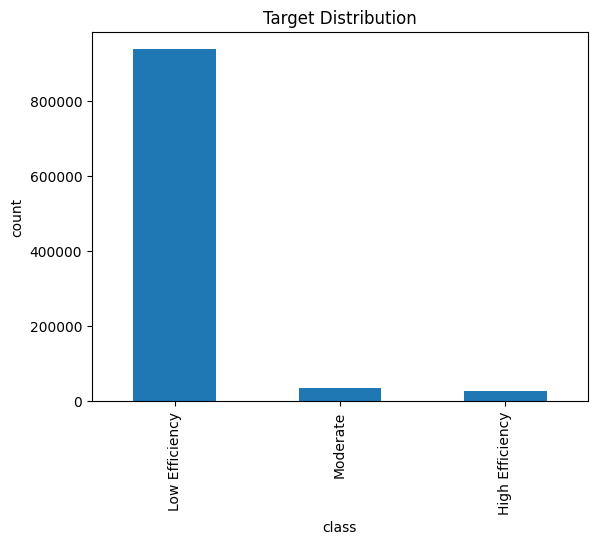

In [24]:
import matplotlib.pyplot as plt
df['calorie_efficiency'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.xlabel('class')
plt.ylabel('count')


In [25]:
print("Skewness:")
print(df.select_dtypes(include=np.number).skew().round(3))
print("\nKurtosis:")
print(df.select_dtypes(include=np.number).kurtosis().round(3))


Skewness:
age                         0.001
steps_per_day               0.054
active_minutes              0.118
calories_burned             0.000
sleep_hours                 0.001
hydration_liters            0.035
bmi                         0.313
workouts_per_week           0.391
muscle_mass_ratio           0.149
body_fat_percentage         0.084
heart_rate_resting         -0.008
heart_rate_avg              0.073
continuous_exercise_days    1.240
efficiency_score            3.954
dtype: float64

Kurtosis:
age                         -1.198
steps_per_day               -0.141
active_minutes              -0.248
calories_burned              0.000
sleep_hours                 -0.104
hydration_liters            -0.147
bmi                         -0.513
workouts_per_week           -0.355
muscle_mass_ratio           -0.321
body_fat_percentage         -0.382
heart_rate_resting          -0.158
heart_rate_avg              -0.186
continuous_exercise_days     0.717
efficiency_score            23.09

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [35]:
from sklearn.preprocessing import LabelEncoder
Encoder=LabelEncoder()
df['calorie_efficiency']=Encoder.fit_transform(df['calorie_efficiency'])
df.head()
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['calorie_efficiency']),df['calorie_efficiency'],test_size=0.2,random_state=42)

In [38]:
model = LogisticRegression(
    penalty='l2',           # regularization type: 'l1', 'l2', 'elasticnet', None
    C=1.0,                  # inverse regularization strength (smaller = stronger)
    solver='lbfgs',         # optimization algorithm: 'lbfgs', 'liblinear', 'saga', 'sag', 'newton-cg'
    max_iter=1000,          # max iterations to converge
    class_weight=None,      # None or 'balanced' for imbalanced data
    random_state=42,        # reproducibility
    tol=1e-4,              # tolerance for stopping criteria
    fit_intercept=True,     # whether to add intercept (bias)
    warm_start=False,       # reuse previous fit as initialization
    verbose=0,              # log output (0=silent, 1=verbose)
    n_jobs=None             # parallel processing (-1 = use all cores)
)



In [39]:
model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` p

In [40]:
model.fit(X_train,y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.h

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` p

Bad pipe message: %s [b'#\xa2\x16\xb1\xed\xecT\xf8\x89\xd3g1\xb9\x06\xb8E\xf9\x9d\x00\x01|\x00']
Bad pipe message: %s [b'\x15o\xf3', b'\xca&V\xd0PB\x0c\xe1\xcb\xe5\x18\xc4\xa0\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00']
Bad pipe message: %s [b'h\x98\x13+4y\xa7PK_V?\x89\xbf$\xea`\r\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x00', b'2\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00']
Bad pipe message: %s [b'\x05\x00\x06']
Bad pipe message: %s [b'k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x9d\x00\x9e\x00\x9f\x00\xa0\x00\xa1\x00\xa2\x00\xa3\x00\xa4\x00\xa5\x00\xa6\x00\xa7\x00\xba\x00\xbb\x00\xbc\x00\xbd\x00\xbe\x00\xbf\x00\xc0\x00\xc1\x00\xc2\x00\xc3\